# System 2107: Meter Audit
- Inputs: meter CSV and supporting metadata only. Raw audit first; approved flag-only processing follows.
- Full-file statistics; representative days/neighborhoods are labeled subsets. The narrow 6.3 MB file fits in memory.
- Run from the repository root or `notebooks/` with pandas/NumPy. SVG figures need no plotting package.
- Preserve raw strings; parsing creates diagnostic series. Missingness uses pandas' default CSV NA tokens.

In [1]:
from pathlib import Path
from datetime import datetime,timedelta
from collections import Counter
import csv,json,hashlib,html,platform
import numpy as np
import pandas as pd
try:
    from IPython.display import display,SVG
except ImportError:
    def display(obj): print(obj.to_string() if isinstance(obj,(pd.Series,pd.DataFrame)) else obj)
    def SVG(data): return data
ROOT=Path.cwd()
if not (ROOT/'data/2107/raw/2107_meter_15m_data.csv').is_file(): ROOT=ROOT.parent
CSV=ROOT/'data/2107/raw/2107_meter_15m_data.csv'; META=ROOT/'data/2107/raw/2107_system_metadata.json'
assert CSV.is_file() and META.is_file(), 'Run from repository root or notebooks/'
def sha256(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''): h.update(block)
    return h.hexdigest()
input_hashes={str(p.relative_to(ROOT)):sha256(p) for p in (CSV,META)}
metadata=json.loads(META.read_text(encoding='utf-8'))
print('Input:',CSV.relative_to(ROOT),'bytes:',CSV.stat().st_size)
print('Python:',platform.python_version(),'pandas:',pd.__version__,'NumPy:',np.__version__)

Input: data\2107\raw\2107_meter_15m_data.csv bytes: 6319525
Python: 3.11.9 pandas: 3.0.6 NumPy: 2.4.6


## 1. Schema and metadata
Verify record widths/header uniqueness before inference. Metadata supports units/aggregation; it does not independently verify calibration or define the meter's interval-label convention.

In [2]:
with CSV.open(newline='',encoding='utf-8-sig') as f:
    reader=csv.reader(f); header=next(reader); record_count=0; bad_widths=[]
    for row in reader:
        record_count+=1
        if len(row)!=len(header): bad_widths.append((record_count,len(row)))
print('Rows:',record_count,'columns:',len(header),'names:',header)
print('Header duplicates:',{k:v for k,v in Counter(header).items() if v>1},'wrong-width records:',bad_widths[:10])
assert not bad_widths and len(header)==len(set(header)), 'Review structural anomalies first'
TIMESTAMP='measured_on'; assert TIMESTAMP in header
CHANNELS=[c for c in header if c!=TIMESTAMP]
frame=pd.read_csv(CSV,dtype={c:'str' for c in CHANNELS},converters={TIMESTAMP:str})
assert len(frame)==record_count
inferred={c:set() for c in header}
for chunk in pd.read_csv(CSV,chunksize=50000):
    for c in header: inferred[c].add(str(chunk[c].dtype))
del chunk
display(pd.DataFrame({'column':header,'inferred_dtypes':[', '.join(sorted(inferred[c])) for c in header]}))
print('Timestamp:',TIMESTAMP,'meter channels:',len(CHANNELS),'duplicate parsed-field rows:',int(frame.duplicated().sum()))
checks=[]
for c in CHANNELS:
    m=metadata['Metrics'].get(c,{})
    checks.append(dict(column=c,metadata_present=bool(m),metric_id=m.get('metric_id'),
        metric_id_matches=str(m.get('metric_id'))==c.rsplit('_',1)[-1],sensor_name=m.get('sensor_name'),
        sensor_name_matches=m.get('sensor_name','').split(' (')[0]==c.rsplit('_meter_',1)[0],
        raw_units=m.get('raw_units'),units=m.get('units'),units_match=str(m.get('units')).lower()=='kw',
        raw_units_match=str(m.get('raw_units')).lower()=='kw',aggregation_type=m.get('aggregation_type'),
        aggregation_matches=m.get('aggregation_type')=='avg',source_type=m.get('source_type'),
        source_id=m.get('source_id'),scale=m.get('calc_scale'),offset=m.get('calc_offset')))
metadata_check=pd.DataFrame(checks); display(metadata_check)
print('Metadata mismatches:')
display(metadata_check.loc[~metadata_check[['metadata_present','metric_id_matches','sensor_name_matches','units_match','raw_units_match','aggregation_matches']].all(axis=1)])
meta_meter={k for k,v in metadata['Metrics'].items() if v.get('source_type')=='METER'}
print('Metadata meter channels absent:',sorted(meta_meter-set(CHANNELS)))
print('CSV channels absent from metadata:',sorted(set(CHANNELS)-set(metadata['Metrics'])))
display(pd.DataFrame(metadata['Meters']).T)
print('Timezone:',metadata['System'].get('timezone_code'),metadata['System'].get('comments'))
print('System-level metadata bounds:',metadata['System'].get('first_timestamp'),metadata['System'].get('last_timestamp'))
METER='meter_revenue_grade_ac_output_meter_149578'; assert CHANNELS==[METER]
raw_time=frame[TIMESTAMP]; parsed=pd.to_datetime(raw_time,format='%Y-%m-%d %H:%M:%S',errors='coerce')
seconds=parsed.diff().dt.total_seconds()
values=pd.to_numeric(frame[METER],errors='coerce')

Rows: 240062 columns: 2 names: ['measured_on', 'meter_revenue_grade_ac_output_meter_149578']
Header duplicates: {} wrong-width records: []
Timestamp: measured_on meter channels: 1 duplicate parsed-field rows: 0
Metadata mismatches:
Metadata meter channels absent: []
CSV channels absent from metadata: []
Timezone: PST8PDT Actual timezone is US/Pacific but needed to use special PST8PDT. System is a participant in the DOE Solar Data Prize 2023
System-level metadata bounds: 2018-12-15 00:15:00 2023-11-15 12:21:50


,column,inferred_dtypes
0,measured_on,str
1,meter_revenue_grade_ac_output_meter_149578,float64


,column,metadata_present,metric_id,metric_id_matches,sensor_name,sensor_name_matches,raw_units,units,units_match,raw_units_match,aggregation_type,aggregation_matches,source_type,source_id,scale,offset
0,meter_revenue_grade_ac_output_meter_149578,True,149578,True,meter_revenue_grade_ac_output (kW),True,kw,kw,True,True,avg,True,METER,None,1.0,0.0


,column,metadata_present,metric_id,metric_id_matches,sensor_name,sensor_name_matches,raw_units,units,units_match,raw_units_match,aggregation_type,aggregation_matches,source_type,source_id,scale,offset


,meter_id,name,manufacturer,model,type,serial_num,comments,time_interval
Meter 0,3133,meter_fss_1,Unknown,,revenue grade,,,L


## 2. Power versus energy
Inspect all-record rises/falls and wall-clock hourly medians. Counterfactual quarter-hour arithmetic uses scalar peaks only to compare interpretations; no measurement series is converted and no energy total is calculated. Plant ratings are sanity references, not validity thresholds.

In [3]:
differences=values.diff()
within_day=raw_time.str[:10].eq(raw_time.shift().str[:10])
quantity_evidence=dict(value_min=values.min(),value_max=values.max(),zeros=int(values.eq(0).sum()),
    increases=int(differences.gt(0).sum()),decreases=int(differences.lt(0).sum()),
    within_day_decreases=int((within_day&differences.lt(0)).sum()),monotonic_accumulation=bool(values.is_monotonic_increasing))
display(pd.Series(quantity_evidence,name='quantity_evidence'))
hourly=pd.DataFrame({'hour':parsed.dt.hour,'value':values}).groupby('hour').value.agg(['size','count','min','median','max'])
display(hourly)
second_largest=values.nlargest(2).iloc[-1]
plant_dc=float(metadata['System']['power(kW DC)']); nominal_ac=24*27.6
hypotheses=pd.DataFrame([
    dict(hypothesis='kW power',raw_second_largest=second_largest,implied_power_kw=second_largest,
         implied_15min_energy_kwh=second_largest*0.25),
    dict(hypothesis='kWh per 15-minute interval',raw_second_largest=second_largest,implied_power_kw=second_largest/0.25,
         implied_15min_energy_kwh=second_largest),
])
display(hypotheses)
print('Sanity references only: metadata DC kW =',plant_dc,'24 x 27.6 nominal AC kW =',nominal_ac)

Sanity references only: metadata DC kW = 893.0 24 x 27.6 nominal AC kW = 662.4000000000001


value_min                     0.0
value_max                 1783.68
zeros                      125925
increases                   56836
decreases                   58934
within_day_decreases        58926
monotonic_accumulation      False
Name: quantity_evidence, dtype: object

,size,count,min,median,max
hour,,,,,
0,9999,9999,0.0,0.0000,0.64
1,10004,10004,0.0,0.0000,0.64
2,9976,9976,0.0,0.0000,0.64
3,10004,10004,0.0,0.0000,0.64
4,10004,10004,0.0,0.0000,0.64
5,10004,10004,0.0,0.0000,6.40
6,10004,10004,0.0,0.0000,55.04
7,10004,10004,0.0,18.5600,314.88
8,10004,10004,0.0,163.2000,525.44


,hypothesis,raw_second_largest,implied_power_kw,implied_15min_energy_kwh
0,kW power,708.48,708.48,177.12
1,kWh per 15-minute interval,708.48,2833.92,708.48


**Conclusion:** average AC power in **kW** is the best-supported interpretation (high confidence). Metadata says `kw`/`avg`; the trace returns near zero overnight and rises/falls during daylight. Thousands of within-day decreases contradict cumulative energy. Treating the ordinary 708.48-scale peak as quarter-hour kWh implies 2833.92 kW, far above the plant's approximate scale; treating it as kW implies 177.12 kWh over a quarter-hour. Daily shape alone cannot distinguish power from interval energy; metadata and scale provide that evidence. Exact averaging duration, calibration, interval start/end labels, and instantaneous-versus-average behavior still need source documentation. The isolated 1783.68 observation does not define normal scale.

## 3. Timestamps and DST
Inspect file-order intervals and raw strings. Conceptual comparison uses reviewed prior audits, not their CSVs: Pacific spring skips and unresolved fall-hour handling. Environment additionally omitted late-evening fall hours; check whether meter export does so.

In [4]:
print('First/last raw:',raw_time.iloc[0],raw_time.iloc[-1])
print('Parsed bounds:',parsed.min(),parsed.max(),'parse failures:',int(parsed.isna().sum()))
display(frame.loc[parsed.isna(),[TIMESTAMP]])
print('Nondecreasing:',parsed.is_monotonic_increasing,'strictly increasing:',bool(seconds.iloc[1:].gt(0).all()))
print('Raw/parsed duplicate timestamps:',int(raw_time.duplicated().sum()),int(parsed.dropna().duplicated().sum()))
display(frame.loc[raw_time.duplicated(keep=False)].head(20))
interval_counts=seconds.value_counts().sort_index().rename('count').to_frame()
interval_counts['pct_intervals']=100*interval_counts['count']/seconds.notna().sum(); display(interval_counts)
print('Modal positive seconds:',float(seconds[seconds>0].mode().iloc[0]),'nonpositive:',int(seconds.le(0).sum()),
    'off-15-minute-grid intervals:',int((seconds.dropna()%900!=0).sum()))
print('Metadata first/last equal CSV:',metadata['System'].get('first_timestamp')==raw_time.iloc[0],metadata['System'].get('last_timestamp')==raw_time.iloc[-1])
def sunday(year,month,ordinal):
    d=datetime(year,month,1); return d+timedelta(days=(6-d.weekday())%7+7*(ordinal-1))
assert parsed.min().year>=2007
spring_slots=[]; dst_rows=[]
for year in range(parsed.min().year,parsed.max().year+1):
    for season,date in [('spring',sunday(year,3,2)),('fall',sunday(year,11,1))]:
        if not parsed.min().normalize()<=date<=parsed.max().normalize(): continue
        day=(parsed>=date)&(parsed<date+timedelta(days=1))
        critical=day & parsed.dt.hour.eq(2 if season=='spring' else 1)
        irregular=(day|day.shift(1,fill_value=False))&seconds.ne(900)&seconds.notna()
        dst_rows.append(dict(year=year,season=season,date=str(date.date()),day_rows=int(day.sum()),
            critical_hour_rows=int(critical.sum()),critical_hour_duplicates=int(raw_time[critical].duplicated().sum()),
            late_hour_rows=int((day&parsed.dt.hour.eq(23)).sum()),
            irregular_intervals=[dict(previous=raw_time.iloc[i-1],current=raw_time.iloc[i],seconds=float(seconds.iloc[i])) for i in np.flatnonzero(irregular)]))
        if season=='spring': spring_slots.extend(pd.date_range(date+timedelta(hours=2),periods=4,freq='15min'))
dst_audit=pd.DataFrame(dst_rows); display(dst_audit)

First/last raw: 2017-01-01 00:15:00 2023-11-09 23:30:00
Parsed bounds: 2017-01-01 00:15:00 2023-11-09 23:30:00 parse failures: 0
Nondecreasing: True strictly increasing: True
Raw/parsed duplicate timestamps: 0 0
Modal positive seconds: 900.0 nonpositive: 0 off-15-minute-grid intervals: 0
Metadata first/last equal CSV: False False


,measured_on


,measured_on,meter_revenue_grade_ac_output_meter_149578


,count,pct_intervals
measured_on,,
900.0,240051,99.995834
4500.0,8,0.003332
87300.0,1,0.000417
173700.0,1,0.000417


,year,season,date,day_rows,critical_hour_rows,critical_hour_duplicates,late_hour_rows,irregular_intervals
0,2017,spring,2017-03-12,92,0,0,4,"[{'previous': '2017-03-12 01:45:00', 'current': '2017-03-12 03:00:00', 'seconds': 4500.0}]"
1,2017,fall,2017-11-05,96,4,0,4,[]
2,2018,spring,2018-03-11,92,0,0,4,"[{'previous': '2018-03-11 01:45:00', 'current': '2018-03-11 03:00:00', 'seconds': 4500.0}]"
3,2018,fall,2018-11-04,96,4,0,4,[]
4,2019,spring,2019-03-10,92,0,0,4,"[{'previous': '2019-03-10 01:45:00', 'current': '2019-03-10 03:00:00', 'seconds': 4500.0}]"
5,2019,fall,2019-11-03,96,4,0,4,[]
6,2020,spring,2020-03-08,92,0,0,4,"[{'previous': '2020-03-08 01:45:00', 'current': '2020-03-08 03:00:00', 'seconds': 4500.0}]"
7,2020,fall,2020-11-01,96,4,0,4,[]
8,2021,spring,2021-03-14,92,0,0,4,"[{'previous': '2021-03-14 01:45:00', 'current': '2021-03-14 03:00:00', 'seconds': 4500.0}]"
9,2021,fall,2021-11-07,96,4,0,4,[]


## 4. Coverage and gaps
Benchmark first-to-last 15-minute wall-clock slots, inclusive. Exclude Pacific spring slots conditionally; fall ambiguity prevents claiming UTC/elapsed-time completeness. Diagnostic slots are not inserted into the dataset. Gap duration is separation between observed endpoints; absent samples = seconds/900 - 1. Short = <=4 non-DST absent slots, long = >4.

In [5]:
assert parsed.notna().all() and parsed.is_monotonic_increasing and not parsed.duplicated().any()
assert (seconds.dropna()%900==0).all()
gaps=pd.DataFrame({'gap_start':raw_time.shift(),'gap_end':raw_time,'seconds':seconds}).loc[seconds>900].copy()
gaps['duration']=pd.to_timedelta(gaps.seconds,unit='s')
gaps['expected_15min_missing']=(gaps.seconds/900-1).astype(int); gaps['dst_spring_slots']=0
observed=pd.DatetimeIndex(parsed)
missing_spring=pd.DatetimeIndex(spring_slots).difference(observed)
for position,count in Counter(np.searchsorted(parsed.to_numpy(),missing_spring.to_numpy())).items():
    gaps.loc[position,'dst_spring_slots']=count
gaps['non_dst_missing']=gaps.expected_15min_missing-gaps.dst_spring_slots
gaps['category']=np.where(gaps.dst_spring_slots>0,
    np.where(gaps.non_dst_missing==0,'DST spring only','DST plus other missing'),
    np.where(gaps.non_dst_missing<=4,'short non-DST','long non-DST'))
display(gaps)
gap_summary=gaps.groupby('category').agg(periods=('seconds','size'),candidate_slots=('expected_15min_missing','sum'),
    dst_slots=('dst_spring_slots','sum'),non_dst_slots=('non_dst_missing','sum')); display(gap_summary)
reference=pd.date_range(parsed.iloc[0],parsed.iloc[-1],freq='15min'); assert observed.isin(reference).all()
conditional_reference=reference[~reference.isin(pd.DatetimeIndex(spring_slots))]
coverage=dict(wall_clock_duration=str(parsed.iloc[-1]-parsed.iloc[0]),rows=len(frame),naive_expected_slots=len(reference),
    spring_slots_excluded=len(reference)-len(conditional_reference),conditional_expected_slots=len(conditional_reference),
    naive_absent_slots=len(reference)-len(frame),non_dst_absent_slots=len(conditional_reference)-len(frame),
    naive_present_pct=100*len(frame)/len(reference),conditional_present_pct=100*len(frame)/len(conditional_reference))
assert gaps.expected_15min_missing.sum()==coverage['naive_absent_slots']
assert gaps.non_dst_missing.sum()==coverage['non_dst_absent_slots']
display(pd.Series(coverage)); longest_gap=gaps.loc[gaps.seconds.idxmax()]
expected_year=pd.Series(conditional_reference.year).value_counts().sort_index()
actual_year=parsed.dt.year.value_counts().sort_index()
yearly=pd.DataFrame({'conditional_expected_slots':expected_year,'rows':actual_year})
yearly['present_pct']=100*yearly.rows/yearly.conditional_expected_slots; display(yearly)

,gap_start,gap_end,seconds,duration,expected_15min_missing,dst_spring_slots,non_dst_missing,category
6727,2017-03-12 01:45:00,2017-03-12 03:00:00,4500.0,0 days 01:15:00,4,4,0,DST spring only
41667,2018-03-11 01:45:00,2018-03-11 03:00:00,4500.0,0 days 01:15:00,4,4,0,DST spring only
76607,2019-03-10 01:45:00,2019-03-10 03:00:00,4500.0,0 days 01:15:00,4,4,0,DST spring only
111547,2020-03-08 01:45:00,2020-03-08 03:00:00,4500.0,0 days 01:15:00,4,4,0,DST spring only
147159,2021-03-14 01:45:00,2021-03-14 03:00:00,4500.0,0 days 01:15:00,4,4,0,DST spring only
159051,2021-07-15 23:45:00,2021-07-18 00:00:00,173700.0,2 days 00:15:00,192,0,192,long non-DST
181907,2022-03-13 01:45:00,2022-03-13 03:00:00,4500.0,0 days 01:15:00,4,4,0,DST spring only
204263,2022-10-31 23:45:00,2022-11-01 01:00:00,4500.0,0 days 01:15:00,4,0,4,short non-DST
216843,2023-03-12 01:45:00,2023-03-12 03:00:00,4500.0,0 days 01:15:00,4,4,0,DST spring only
222687,2023-05-11 23:45:00,2023-05-13 00:00:00,87300.0,1 days 00:15:00,96,0,96,long non-DST


,periods,candidate_slots,dst_slots,non_dst_slots
category,,,,
DST spring only,7,28,28,0
long non-DST,2,288,0,288
short non-DST,1,4,0,4


wall_clock_duration           2503 days 23:15:00
rows                                      240062
naive_expected_slots                      240382
spring_slots_excluded                         28
conditional_expected_slots                240354
naive_absent_slots                           320
non_dst_absent_slots                         292
naive_present_pct                      99.866879
conditional_present_pct                99.878513
dtype: object

,conditional_expected_slots,rows,present_pct
2017,35035,35035,100.000000
2018,35036,35036,100.000000
2019,35036,35036,100.000000
2020,35132,35132,100.000000
2021,35036,34844,99.451992
2022,35036,35032,99.988583
2023,30043,29947,99.680458


## 5. Missing cells and full-file statistics
Separate absent timestamps, recognized NA cells, nonnumeric tokens, and infinities. Quantiles/mean use all finite values; no thresholds are applied.

In [6]:
source_missing=frame[METER].isna(); missing_times=raw_time[source_missing]
invalid=frame[METER].notna() & values.isna(); finite=values[np.isfinite(values)]
statistics=dict(column=METER,count=int(values.notna().sum()),finite_count=len(finite),missing_count=int(source_missing.sum()),
    missing_pct=100*source_missing.mean(),first_missing=missing_times.iloc[0] if len(missing_times) else None,
    last_missing=missing_times.iloc[-1] if len(missing_times) else None,nonnumeric_count=int(invalid.sum()),
    infinity_count=int(np.isinf(values).sum()),min=values.min(),max=values.max(),mean=finite.mean(),median=finite.median(),
    std=finite.std(),zeros=int(values.eq(0).sum()),negatives=int(values.lt(0).sum()),
    max_occurrences=int(values.eq(values.max()).sum()),all_null=bool(source_missing.all()),constant=bool(values.nunique(dropna=True)==1))
statistics.update({f'p{q*100:g}':finite.quantile(q) for q in [.001,.01,.05,.25,.75,.95,.99,.999]})
display(pd.Series(statistics))
display(frame.loc[source_missing|invalid,[TIMESTAMP,METER]])
print('Absent non-DST benchmark timestamps:',coverage['non_dst_absent_slots'],'existing missing measurement rows:',statistics['missing_count'])

Absent non-DST benchmark timestamps: 292 existing missing measurement rows: 0


column              meter_revenue_grade_ac_output_meter_149578
count                                                   240062
finite_count                                            240062
missing_count                                                0
missing_pct                                                0.0
first_missing                                             None
last_missing                                              None
nonnumeric_count                                             0
infinity_count                                               0
min                                                        0.0
max                                                    1783.68
mean                                                153.091341
median                                                     0.0
std                                                 222.516322
zeros                                                   125925
negatives                                              

,measured_on,meter_revenue_grade_ac_output_meter_149578


## 6. Nighttime and sign convention
00:00-04:55 is a clock-night subset conditional on Pacific local time, not an astronomical calculation. Small positive/negative means magnitude <=1 in the stated kW units, for description only. No negative/zero/small reading is classified as invalid.

In [7]:
night=parsed.dt.hour.lt(5); nv=values[night]
night_summary=dict(clock_night_rows=int(night.sum()),valid_count=int(nv.notna().sum()),missing=int(nv.isna().sum()),
    zeros=int(nv.eq(0).sum()),small_positive_0_to_1=int((nv.gt(0)&nv.le(1)).sum()),positive_above_1=int(nv.gt(1).sum()),
    small_negative_minus1_to_0=int((nv.lt(0)&nv.ge(-1)).sum()),negative_below_minus1=int(nv.lt(-1).sum()),
    min=nv.min(),max=nv.max(),median=nv.median(),mean=nv.mean())
display(pd.Series(night_summary))
print('Nonzero clock-night readings and frequencies:'); display(nv[nv.ne(0)&nv.notna()].value_counts().sort_index().rename('count').to_frame())
print('All-file negative observations:'); display(frame.loc[values.lt(0),[TIMESTAMP,METER]])
print('Apparent convention: nonnegative output magnitude; no observed negative import/consumption evidence. Net versus gross export is unresolved.')

Nonzero clock-night readings and frequencies:
All-file negative observations:
Apparent convention: nonnegative output magnitude; no observed negative import/consumption evidence. Net versus gross export is unresolved.


clock_night_rows              49987.000000
valid_count                   49987.000000
missing                           0.000000
zeros                         49852.000000
small_positive_0_to_1           135.000000
positive_above_1                  0.000000
small_negative_minus1_to_0        0.000000
negative_below_minus1             0.000000
min                               0.000000
max                               0.640000
median                            0.000000
mean                              0.001576
dtype: float64

,count
meter_revenue_grade_ac_output_meter_149578,
0.0064,12
0.6400,123


,measured_on,meter_revenue_grade_ac_output_meter_149578


## 7. Daily behavior, zeros, and plateaus
Complete days have 96 unique nominal quarter-hour rows and 96 valid values. Full-file daily/run tables separate present zero records from absent timestamps. Exact plateaus can reflect reporting resolution or operation; they do not establish clipping.

In [8]:
day_key=raw_time.str[:10]
daily=pd.DataFrame({'date':day_key,'value':values}).groupby('date').value.agg(['size','count','min','max','nunique'])
complete=daily['size'].eq(96)&daily['count'].eq(96)
all_zero_days=daily.loc[complete & daily['max'].eq(0)]
print('Complete days:',int(complete.sum()),'complete all-zero days:',len(all_zero_days)); display(all_zero_days)
valid=values.notna()
continuation=valid & valid.shift(fill_value=False) & values.eq(values.shift()) & seconds.eq(900)
run_table=pd.DataFrame({'group':(~continuation).cumsum(),'time':raw_time,'value':values}).loc[valid].groupby('group').agg(
    start=('time','first'),end=('time','last'),value=('value','first'),rows=('value','size'))
run_table['sample_span']=pd.to_timedelta((run_table.rows-1)*900,unit='s')
print('Longest zero runs (not missing cells):'); display(run_table.loc[run_table.value.eq(0)].nlargest(5,'rows'))
print('Longest high-value exact plateaus (value >= full-file p95; descriptive selection only):')
display(run_table.loc[run_table.value.ge(finite.quantile(.95))].nlargest(5,'rows'))
representative_dates=['2019-06-21','2019-12-21','2022-02-01']
assert daily.loc[representative_dates,['size','count']].eq(96).all().all()
print('Representative complete-day statistics (subsets):'); display(daily.loc[representative_dates])

Complete days: 2491 complete all-zero days: 37
Longest zero runs (not missing cells):
Longest high-value exact plateaus (value >= full-file p95; descriptive selection only):
Representative complete-day statistics (subsets):


,size,count,min,max,nunique
date,,,,,
2017-01-02,96,96,0.0,0.0,1
2017-01-03,96,96,0.0,0.0,1
2017-01-04,96,96,0.0,0.0,1
2017-01-05,96,96,0.0,0.0,1
2017-01-06,96,96,0.0,0.0,1
2017-01-07,96,96,0.0,0.0,1
2017-01-08,96,96,0.0,0.0,1
2017-01-09,96,96,0.0,0.0,1
2017-01-10,96,96,0.0,0.0,1


,start,end,value,rows,sample_span
group,,,,,
86562,2022-02-18 13:30:00,2022-03-07 11:00:00,0.0,1623,16 days 21:30:00
1,2017-01-01 00:15:00,2017-01-16 13:45:00,0.0,1495,15 days 13:30:00
35731,2019-02-21 18:00:00,2019-02-24 06:30:00,0.0,243,2 days 12:30:00
103717,2023-03-17 19:15:00,2023-03-20 07:00:00,0.0,240,2 days 11:45:00
51365,2020-01-17 17:00:00,2020-01-19 07:15:00,0.0,154,1 days 14:15:00


,start,end,value,rows,sample_span
group,,,,,
87898,2022-04-05 11:45:00,2022-04-05 13:30:00,646.40,8,0 days 01:45:00
54602,2020-04-01 12:00:00,2020-04-01 13:30:00,668.80,7,0 days 01:30:00
30528,2018-10-14 12:00:00,2018-10-14 13:15:00,705.28,6,0 days 01:15:00
58678,2020-06-16 12:00:00,2020-06-16 13:15:00,700.16,6,0 days 01:15:00
87572,2022-03-29 12:00:00,2022-03-29 13:15:00,677.12,6,0 days 01:15:00


,size,count,min,max,nunique
date,,,,,
2019-06-21,96,96,0.0,564.48,42
2019-12-21,96,96,0.0,84.48,34
2022-02-01,96,96,0.0,708.48,38


## 8. Suspicious observations and magnitude sanity check
Select the maximum, the first ordinary high peak (second-largest value), three largest absolute local contrasts with adjacent 15-minute observations, and the start of the longest zero run. Show context; these are review candidates, not flags. Approximate ratings never define validity.

In [9]:
same_cadence=seconds.eq(900)&seconds.shift(-1).eq(900)
contrast=(values-(values.shift(1)+values.shift(-1))/2).abs().where(same_cadence)
peak_row=int(values.idxmax()); ordinary_peak_row=int(values.nlargest(2).index[-1])
longest_zero=run_table.loc[run_table.value.eq(0)].rows.idxmax()
zero_start=run_table.loc[longest_zero,'start']; zero_row=int(np.flatnonzero(raw_time.eq(zero_start))[0])
chosen={peak_row:'isolated maximum after two zero readings',ordinary_peak_row:'ordinary high plant peak',
        zero_row:'start of longest sustained zero run'}
for i in contrast.nlargest(3).index:
    chosen.setdefault(int(i),'large adjacent-record local contrast')
review_candidates=pd.DataFrame([dict(row=i,timestamp=raw_time.iloc[i],value=values.iloc[i],reason=reason,
    local_contrast=contrast.iloc[i]) for i,reason in sorted(chosen.items())]); display(review_candidates)
for i,reason in sorted(chosen.items()):
    print(reason,'(selected +/-3-record neighborhood)')
    display(pd.DataFrame({'timestamp':raw_time,'value':values,'seconds_since_previous':seconds}).iloc[max(0,i-3):min(len(frame),i+4)])
print('Range ratios: references only, no cleaning cutoffs')
display(pd.DataFrame([
    dict(observation='second-largest reading',value=second_largest,relative_to_893kw_dc=second_largest/plant_dc,
         relative_to_nominal_ac=second_largest/nominal_ac),
    dict(observation='isolated maximum',value=values.max(),relative_to_893kw_dc=values.max()/plant_dc,
         relative_to_nominal_ac=values.max()/nominal_ac)]))
print('The isolated maximum is',values.max()/second_largest,'times the second-largest reading; context is strongly suspicious, not proof of corruption.')

large adjacent-record local contrast (selected +/-3-record neighborhood)
isolated maximum after two zero readings (selected +/-3-record neighborhood)
large adjacent-record local contrast (selected +/-3-record neighborhood)
ordinary high plant peak (selected +/-3-record neighborhood)
start of longest sustained zero run (selected +/-3-record neighborhood)
Range ratios: references only, no cleaning cutoffs
The isolated maximum is 2.5176151761517613 times the second-largest reading; context is strongly suspicious, not proof of corruption.


,row,timestamp,value,reason,local_contrast
0,39692,2018-02-18 12:15:00,0.00,large adjacent-record local contrast,891.84
1,39693,2018-02-18 12:30:00,1783.68,isolated maximum after two zero readings,1444.16
2,39694,2018-02-18 12:45:00,679.04,large adjacent-record local contrast,551.36
3,178104,2022-02-01 11:15:00,708.48,ordinary high plant peak,6.08
4,179745,2022-02-18 13:30:00,0.00,start of longest sustained zero run,169.28


,timestamp,value,seconds_since_previous
39689,2018-02-18 11:30:00,677.12,900.0
39690,2018-02-18 11:45:00,678.40,900.0
39691,2018-02-18 12:00:00,0.00,900.0
39692,2018-02-18 12:15:00,0.00,900.0
39693,2018-02-18 12:30:00,1783.68,900.0
39694,2018-02-18 12:45:00,679.04,900.0
39695,2018-02-18 13:00:00,677.12,900.0


,timestamp,value,seconds_since_previous
39690,2018-02-18 11:45:00,678.40,900.0
39691,2018-02-18 12:00:00,0.00,900.0
39692,2018-02-18 12:15:00,0.00,900.0
39693,2018-02-18 12:30:00,1783.68,900.0
39694,2018-02-18 12:45:00,679.04,900.0
39695,2018-02-18 13:00:00,677.12,900.0
39696,2018-02-18 13:15:00,673.92,900.0


,timestamp,value,seconds_since_previous
39691,2018-02-18 12:00:00,0.00,900.0
39692,2018-02-18 12:15:00,0.00,900.0
39693,2018-02-18 12:30:00,1783.68,900.0
39694,2018-02-18 12:45:00,679.04,900.0
39695,2018-02-18 13:00:00,677.12,900.0
39696,2018-02-18 13:15:00,673.92,900.0
39697,2018-02-18 13:30:00,668.16,900.0


,timestamp,value,seconds_since_previous
178101,2022-02-01 10:30:00,663.68,900.0
178102,2022-02-01 10:45:00,697.60,900.0
178103,2022-02-01 11:00:00,696.96,900.0
178104,2022-02-01 11:15:00,708.48,900.0
178105,2022-02-01 11:30:00,707.84,900.0
178106,2022-02-01 11:45:00,707.84,900.0
178107,2022-02-01 12:00:00,708.48,900.0


,timestamp,value,seconds_since_previous
179742,2022-02-18 12:45:00,656.00,900.0
179743,2022-02-18 13:00:00,660.48,900.0
179744,2022-02-18 13:15:00,338.56,900.0
179745,2022-02-18 13:30:00,0.00,900.0
179746,2022-02-18 13:45:00,0.00,900.0
179747,2022-02-18 14:00:00,0.00,900.0
179748,2022-02-18 14:15:00,0.00,900.0


,observation,value,relative_to_893kw_dc,relative_to_nominal_ac
0,second-largest reading,708.48,0.793371,1.069565
1,isolated maximum,1783.68,1.997402,2.692754


## 9. Diagnostic plots
Three SVG figures: interval counts, full-file distribution, and selected daily/suspicious/zero-run profiles. Window figures plot every present value in each labeled subset; no lines bridge missing timestamps or missing measurements. Raw values remain unchanged.

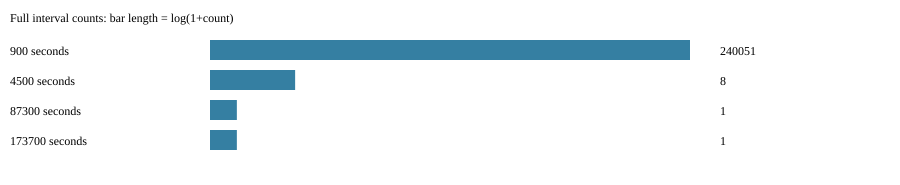

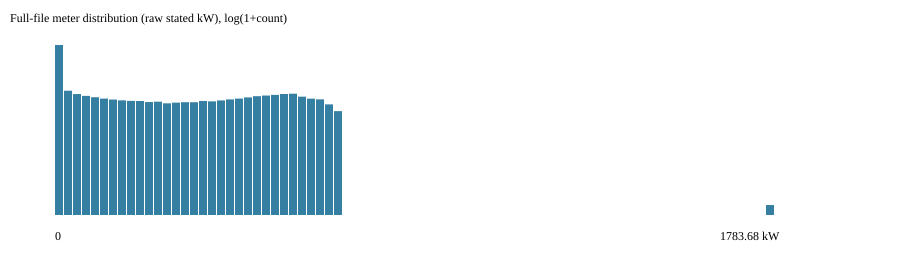

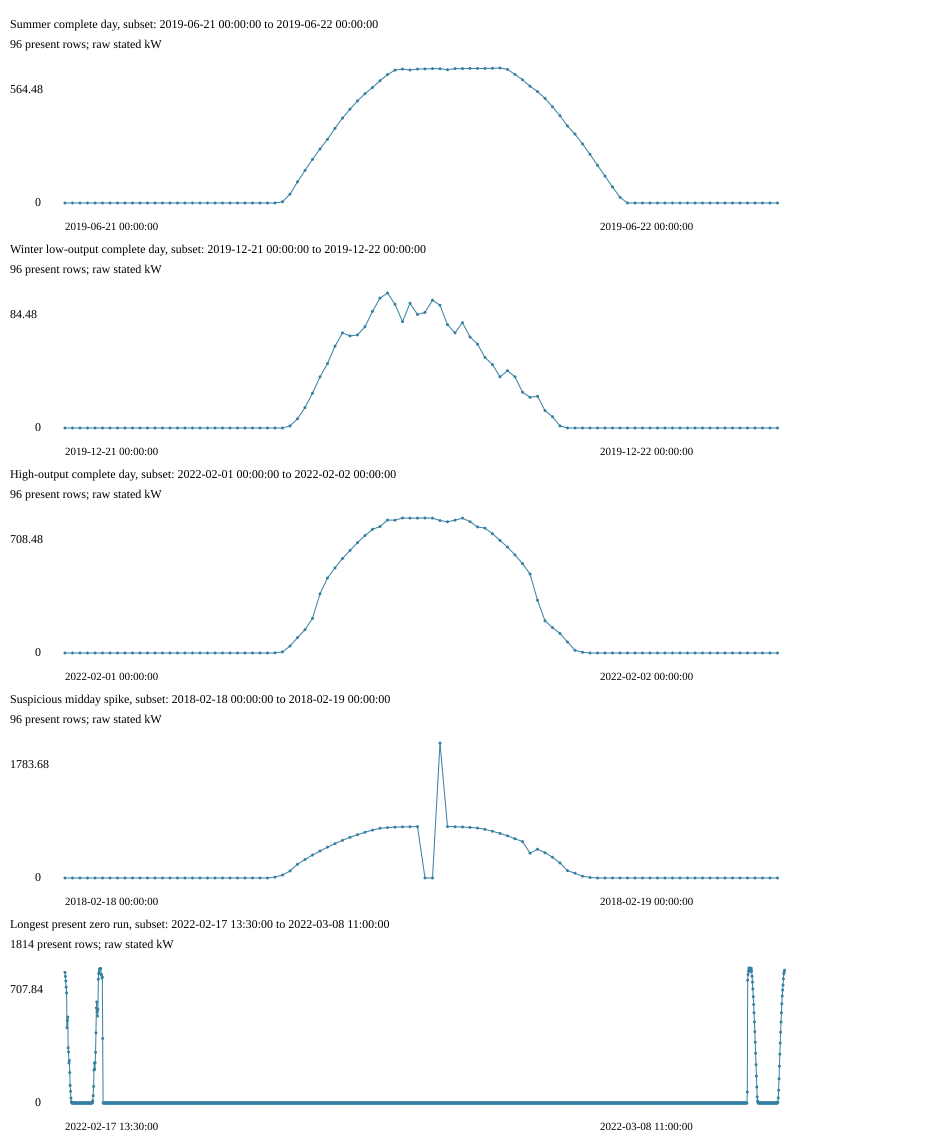

In [10]:
def show_svg(parts,width,height):
    display(SVG(f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}"><rect width="100%" height="100%" fill="white"/>'+''.join(parts)+'</svg>'))
parts=['<text x="10" y="22">Full interval counts: bar length = log(1+count)</text>']; scale=np.log1p(interval_counts['count'].max())
for j,(interval,row) in enumerate(interval_counts.iterrows()):
    y=40+j*30; count=int(row['count'])
    parts.append(f'<text x="10" y="{y+15}">{interval:g} seconds</text><rect x="210" y="{y}" width="{480*np.log1p(count)/scale}" height="20" fill="#357fa2"/><text x="720" y="{y+15}">{count}</text>')
show_svg(parts,900,65+30*len(interval_counts))
counts,edges=np.histogram(finite.to_numpy(),bins=80); scale=np.log1p(counts.max())
parts=['<text x="10" y="22">Full-file meter distribution (raw stated kW), log(1+count)</text>']
for j,count in enumerate(counts):
    h=170*np.log1p(count)/scale
    parts.append(f'<rect x="{55+9*j}" y="{215-h}" width="8" height="{h}" fill="#357fa2"><title>{edges[j]:g} to {edges[j+1]:g}: {count} rows</title></rect>')
parts.append(f'<text x="55" y="240">{edges[0]:g}</text><text x="720" y="240">{edges[-1]:g} kW</text>')
show_svg(parts,900,270)
windows=[(label,pd.Timestamp(date),pd.Timestamp(date)+pd.Timedelta(days=1)) for label,date in zip(
    ['Summer complete day','Winter low-output complete day','High-output complete day'],representative_dates)]
windows.append(('Suspicious midday spike',parsed.iloc[peak_row].normalize(),parsed.iloc[peak_row].normalize()+pd.Timedelta(days=1)))
windows.append(('Longest present zero run',pd.Timestamp(zero_start)-pd.Timedelta(days=1),pd.Timestamp(run_table.loc[longest_zero,'end'])+pd.Timedelta(days=1)))
parts=[]
for panel,(title,start,end) in enumerate(windows):
    top=28+panel*225; mask=(parsed>=start)&(parsed<end); maximum=values[mask].max() or 1
    parts.append(f'<text x="10" y="{top}">{title}, subset: {start} to {end}</text><text x="10" y="{top+20}">{int(mask.sum())} present rows; raw stated kW</text>')
    previous=None
    for i in np.flatnonzero(mask):
        if not np.isfinite(values.iloc[i]): previous=None; continue
        x=65+720*(parsed.iloc[i]-start)/(end-start); y=top+175-135*values.iloc[i]/maximum
        if previous is not None and seconds.iloc[i]==900:
            parts.append(f'<line x1="{previous[0]}" y1="{previous[1]}" x2="{x}" y2="{y}" stroke="#357fa2"/>')
        parts.append(f'<circle cx="{x}" cy="{y}" r="1.5" fill="#357fa2"><title>{raw_time.iloc[i]}: {values.iloc[i]:g}</title></circle>'); previous=(x,y)
    parts.append(f'<text x="10" y="{top+65}">{maximum:g}</text><text x="35" y="{top+178}">0</text><text x="65" y="{top+202}" font-size="11">{start}</text><text x="600" y="{top+202}" font-size="11">{end}</text>')
show_svg(parts,950,225*len(windows)+10)

## 10. Integrity and summary evidence
Recheck both permitted input hashes. This notebook generates no processed dataset or QC-events file.

In [11]:
for path in (CSV,META): assert sha256(path)==input_hashes[str(path.relative_to(ROOT))], 'Input changed during audit'
print('Input SHA-256 checks passed:',input_hashes)
display(pd.Series(coverage)); display(gap_summary); display(pd.Series(statistics)); display(pd.Series(night_summary))
print('Longest gap:',longest_gap.gap_start,longest_gap.gap_end,longest_gap.duration,'candidate absent slots:',longest_gap.expected_15min_missing)

Input SHA-256 checks passed: {'data\\2107\\raw\\2107_meter_15m_data.csv': '7f6c7cf80aae5dd8dd3687a7df95e35d03ffdc5bc0848256a1d76147bce9eb47', 'data\\2107\\raw\\2107_system_metadata.json': '17e4f7f448fcb2bec43f7610b40c1f7f4fc794ccc185e41dcde0514afba73ae5'}
Longest gap: 2021-07-15 23:45:00 2021-07-18 00:00:00 2 days 00:15:00 candidate absent slots: 192


wall_clock_duration           2503 days 23:15:00
rows                                      240062
naive_expected_slots                      240382
spring_slots_excluded                         28
conditional_expected_slots                240354
naive_absent_slots                           320
non_dst_absent_slots                         292
naive_present_pct                      99.866879
conditional_present_pct                99.878513
dtype: object

,periods,candidate_slots,dst_slots,non_dst_slots
category,,,,
DST spring only,7,28,28,0
long non-DST,2,288,0,288
short non-DST,1,4,0,4


column              meter_revenue_grade_ac_output_meter_149578
count                                                   240062
finite_count                                            240062
missing_count                                                0
missing_pct                                                0.0
first_missing                                             None
last_missing                                              None
nonnumeric_count                                             0
infinity_count                                               0
min                                                        0.0
max                                                    1783.68
mean                                                153.091341
median                                                     0.0
std                                                 222.516322
zeros                                                   125925
negatives                                              

clock_night_rows              49987.000000
valid_count                   49987.000000
missing                           0.000000
zeros                         49852.000000
small_positive_0_to_1           135.000000
positive_above_1                  0.000000
small_negative_minus1_to_0        0.000000
negative_below_minus1             0.000000
min                               0.000000
max                               0.640000
median                            0.000000
mean                              0.001576
dtype: float64

# Meter Dataset Audit — Findings Requiring Cleaning Decisions

### A. Observed facts
- One measurement: `meter_revenue_grade_ac_output_meter_149578`, metric 149578. Metadata agrees on sensor name, `kw`, `avg`, scale 1/offset 0; metric `source_id` is null. Equipment metadata says revenue-grade meter; interval marker `L` is undefined here. System-level metadata coverage bounds differ.
- 240,062 rows from `2017-01-01 00:15:00` to `2023-11-09 23:30:00`. Unique, strictly increasing timestamps; no parse failures, duplicate rows, missing measurement cells, negative values, nonnumeric tokens, or infinities.
- Coverage: 2503 days 23:15 of naive wall-clock span; 240,382 nominal slots. Excluding 28 spring slots leaves 240,354 expected slots: 240,062 present (99.87851%), 292 non-DST slots absent. Of 240,061 intervals, 240,051 are 15 minutes (99.99583%). One short gap has four absent samples; two long gaps have 192 and 96 samples. Longest bounding interval: `2021-07-15 23:45:00` to `2021-07-18 00:00:00`, 2 days 00:15. The absent full days are July 16?17, 2021 and May 12, 2023.
- Seven spring skips omit 02:xx. Covered fall days have 96 rows, one set of 01:xx, and the late-evening hour present. Broad Pacific wall-clock behavior matches prior audits; the environment's late-evening fall omission is not present here. Fall interval selection remains unresolved.
- Values range 0?1783.68; second-largest is 708.48. There are 125,925 zeros. Values rise/fall within days rather than accumulating. Clock-night subset: 49,987 rows, 49,852 zeros and 135 positives (123 at 0.64, 12 at 0.0064); no negative or missing clock-night readings.
- 2,491 complete days; 37 have all-zero records. The longest contiguous zero run has 1,623 rows from `2022-02-18 13:30:00` to `2022-03-07 11:00:00`, with records present throughout. Another long zero period precedes the first positive measurements in January 2017. Zero records are not declared missing.
- `2018-02-18 12:30:00` records 1783.68 once, after zeros at 12:00/12:15; nearby readings are around 672?679. High-output days also show exact plateaus around 646?705. These remain raw observations, not clipping/corruption findings.

### B. Tentative interpretations
- **Power versus energy:** average AC power in kW is strongly favored (high confidence) by metadata, solar-like profiles, near-zero nights, and plant-scale magnitudes. Cumulative energy is contradicted by within-day decreases; quarter-hour kWh would imply ordinary peaks around 2834 kW. Instantaneous versus exact interval averaging and interval start/end labels still need documentation.
- Nonnegative production/export magnitude is the apparent sign convention. Small positive nighttime readings may reflect reporting resolution/baseline; no negative-import convention is established. Net versus gross output is unresolved.
- Ordinary peaks near 708 kW are broadly compatible with an approximately 893 kW DC plant, despite exceeding the approximate 662.4 kW nominal inverter aggregate. Ratings are not cleaning limits. The lone 1783.68 peak and preceding zeros are strongly suspicious for an export/measurement artifact, but corruption is not proven; no orders-of-magnitude numerical overflow is evident.
- Long daytime zero runs may represent outages, commissioning, or zero-coded unavailable data; the meter alone cannot distinguish them. Exact plateaus do not prove inverter clipping.
- Pacific spring behavior is supported; fall ambiguity remains. Missing-day gaps should not be interpolated without evidence, and short omissions need a separate policy.

### C. Decisions still required
- Confirm kW/averaging/calibration and interval-label conventions with source documentation. No power/energy conversion appears necessary for a kW model input if confirmed; later integration to energy is a separate decision, not implemented here.
- Decide QC treatment of the exact spike, adjacent zeros, sustained zero periods, nighttime positives, and high plateaus. No rejection or replacement is implemented.
- Confirm sign/net-export conventions, fall handling, and later alignment across datasets.
- Decide gap policies. No cleaning, resampling, interpolation, timestamp conversion, modelling decisions, or processed output.

## Approved cleaning rules
- Preserve every row, timestamp, missing period, and numerical value. Rename the measurement to `meter_ac_power_kw`.
- Approved interpretation: 15-minute average AC power in kW. No energy conversion or timestamp shift.
- Flag the reviewed nighttime positives, exact spike, and two adjacent zeros; no replacements.
- Sustained zero periods remain unresolved for later inverter/irradiance/availability review. Interval labels and fall-DST handling remain unresolved.

In [12]:
import pyarrow as pa
import pyarrow.parquet as pq

EXPECTED_ROWS = 240_062
AUDIT_HASHES = {
    str(CSV.relative_to(ROOT)): '7f6c7cf80aae5dd8dd3687a7df95e35d03ffdc5bc0848256a1d76147bce9eb47',
    str(META.relative_to(ROOT)): '17e4f7f448fcb2bec43f7610b40c1f7f4fc794ccc185e41dcde0514afba73ae5',
}
assert input_hashes == AUDIT_HASHES, 'Inputs differ from the reviewed audit'
assert len(frame) == EXPECTED_ROWS
# Round-trip parsing preserves the original decimal measurements as float64.
raw_power = np.fromiter((float(token) for token in frame[METER]), dtype=np.float64, count=EXPECTED_ROWS)
clean = pd.DataFrame({TIMESTAMP: raw_time.to_numpy(copy=True), 'meter_ac_power_kw': raw_power})
assert np.isfinite(raw_power).all()

## QC-event generation
Reuse the audit's clock-night mask. The spike and two preceding zeros are exact observations documented in the audit; no new threshold is applied.

In [13]:
night_rows = np.flatnonzero(night & values.gt(0))
assert len(night_rows) == 135
reviewed = [
    ('2018-02-18 12:30:00', 1783.68, 'qc_suspect_spike', 'Isolated audited high reading; review pending'),
    ('2018-02-18 12:00:00', 0.0, 'qc_suspect_daytime_zero', 'Audited zero preceding isolated high reading'),
    ('2018-02-18 12:15:00', 0.0, 'qc_suspect_daytime_zero', 'Audited zero preceding isolated high reading'),
]
event_rows = [(int(i), 'qc_suspect_night', 'Reviewed small positive overnight reading') for i in night_rows]
for timestamp, expected_value, flag, reason in reviewed:
    matches = np.flatnonzero(raw_time.eq(timestamp))
    assert len(matches) == 1
    i = int(matches[0])
    assert raw_power[i] == expected_value
    event_rows.append((i, flag, reason))
qc = pd.DataFrame([
    {TIMESTAMP: raw_time.iloc[i], 'raw_value': raw_power[i], 'flag': flag, 'reason': reason}
    for i, flag, reason in event_rows
]).sort_values([TIMESTAMP, 'flag'], kind='stable').reset_index(drop=True)
assert not qc.duplicated([TIMESTAMP, 'flag']).any()
display(qc.groupby('flag').size().rename('events').to_frame())

,events
flag,
qc_suspect_daytime_zero,2
qc_suspect_night,135
qc_suspect_spike,1


## Parquet output
Write only the two approved derived files. Measurements remain in kW; no values or timestamps are changed.

In [14]:
assert {str(p.relative_to(ROOT)): sha256(p) for p in (CSV, META)} == AUDIT_HASHES
out_dir = ROOT / 'data/2107/processed'
out_dir.mkdir(parents=True, exist_ok=True)
clean_path = out_dir / '2107_meter_clean.parquet'
qc_path = out_dir / '2107_meter_qc_events.parquet'
clean_schema = pa.schema([(TIMESTAMP, pa.string()), ('meter_ac_power_kw', pa.float64())])
qc_schema = pa.schema([(TIMESTAMP, pa.string()), ('raw_value', pa.float64()), ('flag', pa.string()), ('reason', pa.string())])
for path, data, schema in [(clean_path, clean, clean_schema), (qc_path, qc, qc_schema)]:
    pq.write_table(pa.Table.from_pandas(data, schema=schema, preserve_index=False), path,
                   compression='snappy', row_group_size=50_000)
    print(path.relative_to(ROOT))

data\2107\processed\2107_meter_clean.parquet
data\2107\processed\2107_meter_qc_events.parquet


## Validation
Compare every output row with an independent round-trip read of the raw CSV. Verify exact QC membership, schemas, and unchanged input hashes.

In [15]:
raw_check = pd.read_csv(CSV, dtype={METER: np.float64}, converters={TIMESTAMP: str}, float_precision='round_trip')
clean_table = pq.read_table(clean_path)
qc_table = pq.read_table(qc_path)
result = clean_table.to_pandas()
qc_result = qc_table.to_pandas()
assert clean_table.schema.remove_metadata() == clean_schema
assert qc_table.schema.remove_metadata() == qc_schema
assert len(result) == len(raw_check) == EXPECTED_ROWS
assert list(result.columns) == [TIMESTAMP, 'meter_ac_power_kw']
assert np.array_equal(result[TIMESTAMP].to_numpy(), raw_check[TIMESTAMP].to_numpy())
assert np.array_equal(result['meter_ac_power_kw'].to_numpy(), raw_check[METER].to_numpy(), equal_nan=True)
assert np.array_equal(result['meter_ac_power_kw'].isna(), raw_check[METER].isna())
assert np.array_equal(result['meter_ac_power_kw'].eq(0), raw_check[METER].eq(0))
pd.testing.assert_frame_equal(qc_result, qc, check_exact=True)
expected_counts = {'qc_suspect_night': 135, 'qc_suspect_spike': 1, 'qc_suspect_daytime_zero': 2}
assert qc_result['flag'].value_counts().to_dict() == expected_counts
for flag in expected_counts:
    expected_indices = [i for i, event_flag, _ in event_rows if event_flag == flag]
    actual = qc_result.loc[qc_result['flag'].eq(flag)]
    assert set(actual[TIMESTAMP]) == set(raw_check.iloc[expected_indices][TIMESTAMP])
lookup = raw_check.set_index(TIMESTAMP)[METER]
assert lookup.index.is_unique
assert np.array_equal(qc_result['raw_value'].to_numpy(), lookup.loc[qc_result[TIMESTAMP]].to_numpy())
assert qc_result.loc[qc_result['flag'].eq('qc_suspect_daytime_zero'), 'raw_value'].eq(0).all()
assert qc_result.loc[qc_result['flag'].eq('qc_suspect_spike'), 'raw_value'].tolist() == [1783.68]
assert {str(p.relative_to(ROOT)): sha256(p) for p in (CSV, META)} == AUDIT_HASHES
print('PASS: 240,062 rows; exact timestamps/order, all kW values, zeros and gaps preserved.')
print('PASS: QC observations/counts, Parquet schemas/readback, raw CSV and metadata hashes.')
print('No numerical replacements or kW-to-kWh conversion. Interval labels, DST and zero periods remain for later review.')

PASS: 240,062 rows; exact timestamps/order, all kW values, zeros and gaps preserved.
PASS: QC observations/counts, Parquet schemas/readback, raw CSV and metadata hashes.
No numerical replacements or kW-to-kWh conversion. Interval labels, DST and zero periods remain for later review.
